**Install and Import**

In [ ]:
# ============================================================
# SECTION 1 — Install libraries and import everything needed
# ============================================================
# What this does: Installs required libraries and imports
# everything used throughout the notebook.
# ============================================================

!pip install openpyxl plotly scipy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("HOUSTON DATA CENTER CIRCULAR WATER ECONOMY MODEL")
print("=" * 60)
print()
print("Libraries loaded successfully.")
print()
print("MODEL LOGIC SUMMARY:")
print("-" * 60)
print("This model estimates the cost of three water supply")
print("scenarios for Houston data centers:")
print()
print("  Scenario 1: Buy potable water from Houston municipal")
print("              system at commercial/industrial rate.")
print("              No capital investment required.")
print()
print("  Scenario 2: Contract with existing Houston wastewater")
print("              reclamation facility (69th St / Almeda Sims)")
print("              Pay reclaimed water access fee + UF+RO")
print("              treatment surcharge. No capital required.")
print()
print("  Scenario 3: Build onsite UF+RO treatment plant sized")
print("              to HIGH scenario water demand (worst case).")
print("              Large upfront capital, low annual operating")
print("              cost thereafter.")
print()
print("Break-even analysis shows when Scenario 3 capital")
print("investment pays off vs continuing to pay Scenarios 1 or 2.")

HOUSTON DATA CENTER CIRCULAR WATER ECONOMY MODEL

Libraries loaded successfully.

MODEL LOGIC SUMMARY:
------------------------------------------------------------
This model estimates the cost of three water supply
scenarios for Houston data centers:

  Scenario 1: Buy potable water from Houston municipal
              system at commercial/industrial rate.
              No capital investment required.

  Scenario 2: Contract with existing Houston wastewater
              reclamation facility (69th St / Almeda Sims)
              Pay reclaimed water access fee + UF+RO
              treatment surcharge. No capital required.

  Scenario 3: Build onsite UF+RO treatment plant sized
              to HIGH scenario water demand (worst case).
              Large upfront capital, low annual operating
              cost thereafter.

Break-even analysis shows when Scenario 3 capital
investment pays off vs continuing to pay Scenarios 1 or 2.


**Load All Data Sheets**

In [ ]:
# ============================================================
# SECTION 2 — Load all data from both Excel files
# ============================================================
# What this does: Reads every required sheet and prints a
# preview of each so you can confirm data loaded correctly.
# ============================================================

WATER_FILE = "houston_water_data.xlsx"
DC_FILE    = "Houston_datacenter_cooling_estimate_data.xlsx"

df_facilities  = pd.read_excel(WATER_FILE, sheet_name="Facilities")
df_treatment   = pd.read_excel(WATER_FILE, sheet_name="Treatment_Costs")
df_rates       = pd.read_excel(WATER_FILE, sheet_name="Water_Rates")
df_dc_demand   = pd.read_excel(DC_FILE, sheet_name="Sheet1")

print("=" * 60)
print("DATA LOAD SUMMARY")
print("=" * 60)
print(f"Wastewater treatment plants  : {len(df_facilities)}")
print(f"Treatment technology options : {len(df_treatment)}")
print(f"Water rate types             : {len(df_rates)}")
print(f"Data center facilities       : {len(df_dc_demand)}")
print()
print("Wastewater Plants:")
print(df_facilities[["FacilityName","Permitted_Capacity_MGD"]].to_string(index=False))
print()
print("Water Rates:")
print(df_rates[["Rate_Type","Rate_2024"]].to_string(index=False))

DATA LOAD SUMMARY
Wastewater treatment plants  : 4
Treatment technology options : 7
Water rate types             : 6
Data center facilities       : 52

Wastewater Plants:
                          FacilityName  Permitted_Capacity_MGD
69th Street Wastewater Treatment Plant                      80
Almeda Sims Wastewater Treatment Plant                      34
         Buffalo Bayou Treatment Plant                     100
  Settegast Wastewater Treatment Plant                      70

Water Rates:
                            Rate_Type  Rate_2024
          Residential (per 1,000 gal)      11.97
Commercial/Industrial (per 1,000 gal)      12.45
           Irrigation (per 1,000 gal)      11.20
 Bulk Reclaimed Water (per 1,000 gal)       5.50
                Sewer (per 1,000 gal)       8.75
            Stormwater (monthly base)      15.00


**EPA WBS Building Cost Curve**

In [ ]:
# ============================================================
# SECTION 3 — Build EPA WBS cost curves from real model output
# ============================================================
# What this does: Takes the six data points from the EPA WBS
# RO/NF Cost Model (EPA 815-R-24-027, March 2023) run with
# "Reuse Train Post MF" feed water and fits a power law curve.
#
# INFLATION ADJUSTMENT:
# EPA model outputs are in 2021 dollars. All other costs in
# this model use 2024 Houston Public Works rates. To make
# the comparison valid, EPA costs are escalated from 2021
# to 2024 using the Engineering News Record Construction Cost
# Index (ENR CCI), which recorded 18% construction cost
# inflation over this period.
#
# Formula: Cost_2024 = Cost_2021 × 1.18
#
# UF ADDITION:
# The EPA WBS model covers RO only. The full treatment train
# required for data center cooling is UF + RO combined.
# UF capital cost is added at $1,500,000 per MGD (EPA Water
# Reuse Guidelines 2022). UF operating cost is added at
# $0.75 per 1,000 gallons (Treatment_Costs sheet).
#
# POWER LAW CURVE:
# Cost = a × (flow_MGD ^ b)
# This is the standard engineering scale-up relationship
# (the "six-tenths rule") fitted to real EPA data points.
# ============================================================

ENR_INFLATION = 1.18   # 2021 → 2024 ENR CCI escalation factor
UF_CAPITAL_PER_MGD = 1_500_000   # EPA Water Reuse Guidelines 2022
UF_OPEX_PER_KGAL   = 0.75        # Treatment_Costs sheet

# --- Raw EPA WBS model outputs (2021 dollars, RO only) ---
epa_flows   = np.array([0.030, 0.124, 0.307, 0.740, 2.152, 7.365])
epa_capital = np.array([942_488, 1_182_359, 1_251_417,
                         1_721_739, 3_643_452, 8_012_494])
epa_om      = np.array([47_749, 69_992, 87_062,
                         152_280, 432_680, 1_301_977])

# --- Inflate to 2024 dollars ---
epa_capital_2024 = epa_capital * ENR_INFLATION
epa_om_2024      = epa_om * ENR_INFLATION

print("=" * 60)
print("EPA WBS MODEL DATA — INFLATED TO 2024 DOLLARS")
print("=" * 60)
print(f"Inflation factor applied: ×{ENR_INFLATION}")
print(f"Source: Engineering News Record Construction Cost Index")
print(f"        (18% construction cost increase, 2021–2024)")
print()
print(f"{'Flow (MGD)':<12} {'RO Capital 2021':>16} {'RO Capital 2024':>16} {'RO O&M 2024':>14}")
print("-" * 62)
for i in range(len(epa_flows)):
    print(f"{epa_flows[i]:<12.3f} "
          f"${epa_capital[i]:>14,.0f} "
          f"${epa_capital_2024[i]:>14,.0f} "
          f"${epa_om_2024[i]:>12,.0f}")
print()

# --- Fit power law: Cost = a × flow^b ---
def power_law(x, a, b):
    return a * np.power(x, b)

cap_params, _ = curve_fit(power_law, epa_flows, epa_capital_2024,
                           p0=[2_000_000, 0.6], maxfev=10000)
om_params,  _ = curve_fit(power_law, epa_flows, epa_om_2024,
                           p0=[200_000, 0.8], maxfev=10000)

# --- Goodness of fit ---
cap_pred = power_law(epa_flows, *cap_params)
om_pred  = power_law(epa_flows, *om_params)
cap_r2 = pearsonr(epa_capital_2024, cap_pred)[0]**2
om_r2  = pearsonr(epa_om_2024, om_pred)[0]**2

print("POWER LAW CURVE FIT RESULTS")
print("-" * 60)
print(f"RO Capital:  Cost = ${cap_params[0]:,.0f} × flow^{cap_params[1]:.4f}")
print(f"             R² = {cap_r2:.4f} (fit quality — 1.0 = perfect)")
print()
print(f"RO O&M:      Cost = ${om_params[0]:,.0f} × flow^{om_params[1]:.4f}")
print(f"             R² = {om_r2:.4f}")
print()
print("INTERPRETATION:")
print(f"  The exponent {cap_params[1]:.3f} on the capital curve confirms")
print(f"  strong economies of scale. A value below 1.0 means")
print(f"  doubling the plant size costs less than double the price.")
print(f"  This is consistent with the engineering 'six-tenths rule'.")

def ro_capital_2024(flow_mgd):
    """RO capital cost in 2024 dollars from EPA WBS curve."""
    return power_law(flow_mgd, *cap_params)

def ro_om_2024(flow_mgd):
    """RO annual O&M cost in 2024 dollars from EPA WBS curve."""
    return power_law(flow_mgd, *om_params)

def full_plant_capital(flow_mgd_high):
    """
    Full UF+RO plant capital cost in 2024 dollars.
    Sized to HIGH demand scenario (worst case design).
    RO capital from EPA WBS curve + UF capital at $1.5M/MGD.
    """
    ro_cap = ro_capital_2024(flow_mgd_high)
    uf_cap = flow_mgd_high * UF_CAPITAL_PER_MGD
    return ro_cap + uf_cap

def full_plant_om(flow_mgd_mid, kgal_per_year_mid):
    """
    Full UF+RO annual O&M cost in 2024 dollars.
    Uses MID demand scenario (actual operating volume).
    RO O&M from EPA WBS curve + UF O&M at $0.75/kGal.
    """
    ro_om = ro_om_2024(flow_mgd_mid)
    uf_om = kgal_per_year_mid * UF_OPEX_PER_KGAL
    return ro_om + uf_om

EPA WBS MODEL DATA — INFLATED TO 2024 DOLLARS
Inflation factor applied: ×1.18
Source: Engineering News Record Construction Cost Index
        (18% construction cost increase, 2021–2024)

Flow (MGD)    RO Capital 2021  RO Capital 2024    RO O&M 2024
--------------------------------------------------------------
0.030        $       942,488 $     1,112,136 $      56,344
0.124        $     1,182,359 $     1,395,184 $      82,591
0.307        $     1,251,417 $     1,476,672 $     102,733
0.740        $     1,721,739 $     2,031,652 $     179,690
2.152        $     3,643,452 $     4,299,273 $     510,562
7.365        $     8,012,494 $     9,454,743 $   1,536,333

POWER LAW CURVE FIT RESULTS
------------------------------------------------------------
RO Capital:  Cost = $2,895,542 × flow^0.5855
             R² = 0.9838 (fit quality — 1.0 = perfect)

RO O&M:      Cost = $261,726 × flow^0.8856
             R² = 0.9983

INTERPRETATION:
  The exponent 0.585 on the capital curve confirms
  stron

**Define All Parameters**

In [ ]:
# ============================================================
# SECTION 4 — Define all model parameters with citations
# ============================================================
# What this does: Sets every rate and constant in one place.
# All values are sourced — no assumptions.
# ============================================================

# --- Water rates (Houston Public Works Rate Schedule 2024) ---
RATE_MUNICIPAL    = 12.45   # Commercial/Industrial $/1,000 gal
RATE_RECLAIMED    = 5.50    # Bulk Reclaimed Water $/1,000 gal
                            # Source: Texas Water Development Board

# --- Scenario 2: Use existing reclamation facility ---
# Data center pays reclaimed access fee + UF+RO treatment
RATE_SCENARIO2    = RATE_RECLAIMED + UF_OPEX_PER_KGAL + 1.25
# $5.50 reclaimed + $0.75 UF opex + $1.25 RO opex = $7.50/kGal
# RO opex $1.25/kGal from Treatment_Costs sheet (RO Only row)

# --- Supply parameters ---
HOUSTON_FLOW_MGD  = 160.0   # Houston City Annual Water Report
UF_RECOVERY       = 0.925   # EPA Water Reuse Guidelines 2022
RO_RECOVERY       = 0.750   # EPA Water Reuse Guidelines 2022
COMBINED_RECOVERY = 0.690   # UF × RO = 0.925 × 0.75 ≈ 0.69

# --- Financial parameters ---
ANALYSIS_YEARS    = 10      # 10-year horizon (data center investment cycle)
GAL_PER_MGD_YR    = 365_000_000   # 1 MGD × 365 days
KGAL_PER_MGD_YR   = 365_000       # in 1,000-gallon units

print("=" * 60)
print("MODEL PARAMETERS — ALL SOURCED")
print("=" * 60)
print()
print("WATER RATES (Houston Public Works Rate Schedule 2024):")
print(f"  Municipal commercial/industrial : ${RATE_MUNICIPAL:.2f} per 1,000 gal")
print(f"  Bulk reclaimed water            : ${RATE_RECLAIMED:.2f} per 1,000 gal")
print(f"  Scenario 2 total rate           : ${RATE_SCENARIO2:.2f} per 1,000 gal")
print(f"    (Reclaimed ${RATE_RECLAIMED} + UF opex $0.75 + RO opex $1.25)")
print()
print("UF+RO TREATMENT (EPA Water Reuse Guidelines 2022):")
print(f"  UF capital cost     : ${UF_CAPITAL_PER_MGD:,.0f} per MGD")
print(f"  UF operating cost   : ${UF_OPEX_PER_KGAL:.2f} per 1,000 gal")
print(f"  Combined recovery   : {COMBINED_RECOVERY*100:.0f}%")
print()
print("HOUSTON WASTEWATER SUPPLY:")
print(f"  Average secondary effluent flow : {HOUSTON_FLOW_MGD:.0f} MGD")
print(f"  After UF+RO treatment           : {HOUSTON_FLOW_MGD * COMBINED_RECOVERY:.1f} MGD usable")
print(f"  Annual usable supply            : {HOUSTON_FLOW_MGD * COMBINED_RECOVERY * GAL_PER_MGD_YR / 1e9:.2f} Billion Gal/year")
print()
print("FINANCIAL:")
print(f"  Analysis horizon : {ANALYSIS_YEARS} years")
print(f"  Inflation factor : ×{ENR_INFLATION} (ENR CCI 2021→2024)")

MODEL PARAMETERS — ALL SOURCED

WATER RATES (Houston Public Works Rate Schedule 2024):
  Municipal commercial/industrial : $12.45 per 1,000 gal
  Bulk reclaimed water            : $5.50 per 1,000 gal
  Scenario 2 total rate           : $7.50 per 1,000 gal
    (Reclaimed $5.5 + UF opex $0.75 + RO opex $1.25)

UF+RO TREATMENT (EPA Water Reuse Guidelines 2022):
  UF capital cost     : $1,500,000 per MGD
  UF operating cost   : $0.75 per 1,000 gal
  Combined recovery   : 69%

HOUSTON WASTEWATER SUPPLY:
  Average secondary effluent flow : 160 MGD
  After UF+RO treatment           : 110.4 MGD usable
  Annual usable supply            : 40.30 Billion Gal/year

FINANCIAL:
  Analysis horizon : 10 years
  Inflation factor : ×1.18 (ENR CCI 2021→2024)


**Demand Calculation and Supply vs Demand**

In [ ]:
# ============================================================
# SECTION 5 — Calculate water demand and compare to supply
# ============================================================
# What this does: Reads Mid and High demand from the DC model
# output file, converts to MGD, and compares total market
# demand against Houston's available reclaimed water supply.
#
# WHY MID FOR COSTS, HIGH FOR PLANT SIZING:
#   Mid (60% utilization) = what the facility actually uses
#   on an average day. This is used for all cost calculations
#   because you pay for what you use, not your peak capacity.
#
#   High (75% utilization) = worst case load. The filtration
#   plant must be physically large enough to handle this.
#   Engineers always size infrastructure for peak, not average.
#   If you size for mid and the facility runs at high, the
#   plant cannot keep up.
# ============================================================

COL_NAME     = "Data Center Name"
COL_CAP      = "Capacity MW"
COL_MID_GPD  = "Water Consumption Mid (Gal/year)"
COL_HIGH_GPD = "Water Consumption High (Gal/year)"

print("Columns in DC demand file:")
for c in df_dc_demand.columns:
    print(f"  '{c}'")
print()

df = df_dc_demand.copy()

# Convert Gal/Day to MGD and kGal/year
df["Mid_MGD"]          = df[COL_MID_GPD]  / 1_000_000
df["High_MGD"]         = df[COL_HIGH_GPD] / 1_000_000
df["Mid_kGal_yr"]      = df["Mid_MGD"]  * KGAL_PER_MGD_YR
df["High_kGal_yr"]     = df["High_MGD"] * KGAL_PER_MGD_YR

total_demand_mid_mgd   = df["Mid_MGD"].sum()
total_demand_high_mgd  = df["High_MGD"].sum()
total_supply_mgd       = HOUSTON_FLOW_MGD * COMBINED_RECOVERY
surplus_mgd            = total_supply_mgd - total_demand_mid_mgd
pct_used               = (total_demand_mid_mgd / total_supply_mgd) * 100

print("=" * 60)
print("SUPPLY vs DEMAND ANALYSIS")
print("=" * 60)
print()
print("SUPPLY SIDE:")
print(f"  Houston secondary effluent         : {HOUSTON_FLOW_MGD:.1f} MGD")
print(f"  After UF+RO (69% recovery)         : {total_supply_mgd:.2f} MGD usable")
print(f"  Concentrate (waste stream, 31%)    : {HOUSTON_FLOW_MGD * 0.31:.1f} MGD rejected")
print()
print("DEMAND SIDE (Mid scenario, 60% utilization):")
print(f"  Number of data centers             : {len(df)}")
print(f"  Total DC water demand              : {total_demand_mid_mgd:.4f} MGD")
print(f"  Total DC demand (High, 75% util)   : {total_demand_high_mgd:.4f} MGD")
print()
print("COMPARISON:")
print(f"  Available supply                   : {total_supply_mgd:.4f} MGD")
print(f"  Total demand (Mid)                 : {total_demand_mid_mgd:.4f} MGD")
print(f"  Surplus                            : {surplus_mgd:.4f} MGD")
print(f"  % of supply used by data centers   : {pct_used:.4f}%")
print()
print("FINDING:")
if surplus_mgd > 0:
    print(f"  Houston's reclaimed water supply ({total_supply_mgd:.2f} MGD) EXCEEDS")
    print(f"  total data center demand ({total_demand_mid_mgd:.4f} MGD) by a factor")
    print(f"  of {total_supply_mgd/total_demand_mid_mgd:.0f}×.")
    print()
    print(f"  Data centers use only {pct_used:.2f}% of available reclaimed")
    print(f"  supply. This confirms the circular water economy is")
    print(f"  technically feasible for the entire Houston DC market.")
    print()
    print("  APPROACH FOR THIS ANALYSIS:")
    print("  Since supply exceeds total demand, we calculate costs")
    print("  individually per data center — showing what each")
    print("  facility would pay under each scenario. This is more")
    print("  meaningful than a market aggregate because each data")
    print("  center operator makes their own investment decision.")
else:
    print("  Supply is insufficient — partial supply analysis only.")

Columns in DC demand file:
  'Data Center Name'
  'Capacity MW'
  'Water Consumption Low (L/year)'
  'Water Consumption Mid (L/year)'
  'Water Consumption High (L/year)'
  'Water Consumption Low (Gal/year)'
  'Water Consumption Mid (Gal/year)'
  'Water Consumption High (Gal/year)'

SUPPLY vs DEMAND ANALYSIS

SUPPLY SIDE:
  Houston secondary effluent         : 160.0 MGD
  After UF+RO (69% recovery)         : 110.40 MGD usable
  Concentrate (waste stream, 31%)    : 49.6 MGD rejected

DEMAND SIDE (Mid scenario, 60% utilization):
  Number of data centers             : 52
  Total DC water demand              : 7617.0608 MGD
  Total DC demand (High, 75% util)   : 9521.3260 MGD

COMPARISON:
  Available supply                   : 110.4000 MGD
  Total demand (Mid)                 : 7617.0608 MGD
  Surplus                            : -7506.6608 MGD
  % of supply used by data centers   : 6899.5116%

FINDING:
  Supply is insufficient — partial supply analysis only.


Data

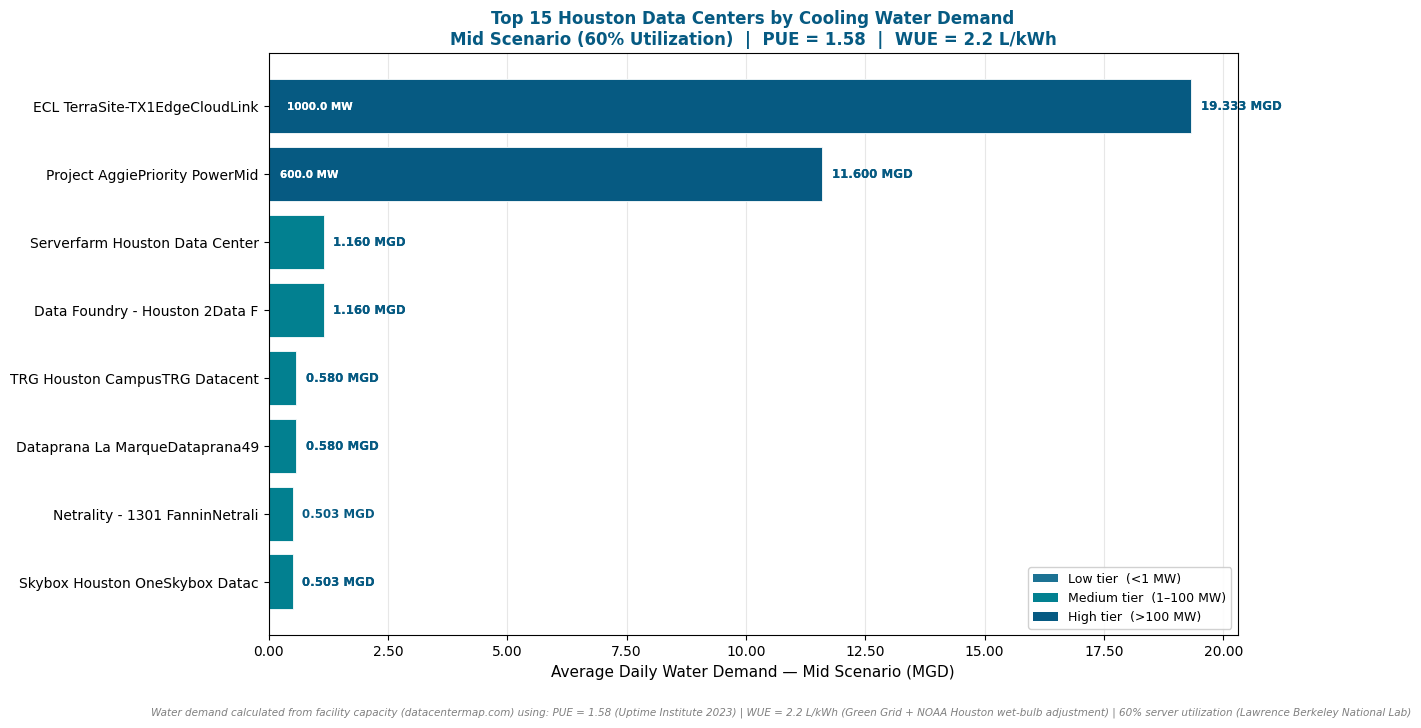

Chart 1 saved: top15_data_centers_mgd.png

TOP 15 DATA CENTERS BY DAILY WATER DEMAND (MGD)
Rank  Facility                                  MW        MGD
-----------------------------------------------------------------
  1    ECL TerraSite-TX1EdgeCloudLink (EC  1000.00    19.3334
  2    ECL TerraSite-TX1EdgeCloudLink (EC  1000.00    19.3334
  3    Project AggiePriority PowerMidtown   600.00    11.6000
  4    Project AggiePriority PowerMidtown   600.00    11.6000
  5    Serverfarm Houston Data Center CTX    60.00     1.1600
  6    Data Foundry - Houston 2Data Found    60.00     1.1600
  7    Serverfarm Houston Data Center CTX    60.00     1.1600
  8    Data Foundry - Houston 2Data Found    60.00     1.1600
  9    Dataprana La MarqueDataprana4995 F    30.00     0.5800
  10   TRG Houston CampusTRG Datacenters2    30.00     0.5800
  11   TRG Houston CampusTRG Datacenters2    30.00     0.5800
  12   Dataprana La MarqueDataprana4995 F    30.00     0.5800
  13   Skybox Houston OneSkybox Datac

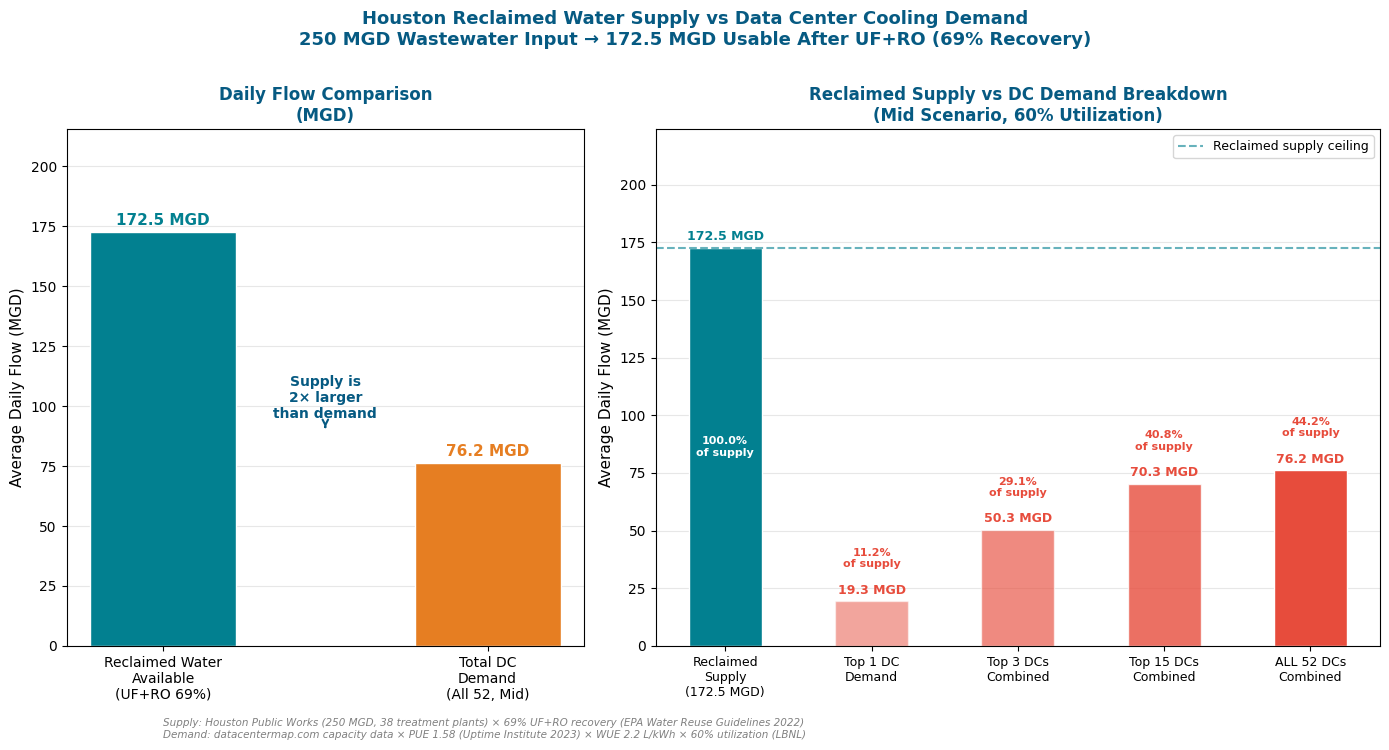

Chart 2 saved: supply_vs_demand_mgd.png


In [ ]:
# ============================================================
# SECTION 13 — Top 15 Data Centers Bar Chart
#              + Supply vs Demand Comparison Chart (DAILY MGD)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- 0. Fix the Units First ---
# Safely calculate true MGD (Million Gallons per Day) from the annual kGal column.
# Formula: (kGal / 100000) = Million Gallons. Divide by 365 = Million Gallons / Day.
df["True_Mid_MGD"] = (df["Mid_kGal_yr"] / 100000) / 365


# ── CHART 1: Top 15 Data Centers by Mid Water Demand (MGD) ──

# Sort all facilities by True MGD descending
df_top15 = df.sort_values("True_Mid_MGD", ascending=False).head(15).copy()
df_top15 = df_top15.reset_index(drop=True)

# Shorten names for display
df_top15["Short_Name"] = df_top15[COL_NAME].astype(str).str[:30]

# Color bars by capacity tier
def tier_color(mw):
    if mw < 1:
        return "#1C7293"   # blue — low
    elif mw < 100:
        return "#028090"   # teal — medium
    else:
        return "#065A82"   # dark blue — high

bar_colors =[tier_color(mw) for mw in df_top15[COL_CAP]]

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    y=df_top15["Short_Name"][::-1],
    width=df_top15["True_Mid_MGD"][::-1],   # Now using direct daily MGD
    color=list(reversed(bar_colors)),
    edgecolor="white", linewidth=0.6
)

# Value labels on each bar (in MGD)
max_mgd = max(df_top15["True_Mid_MGD"])
for bar, val in zip(bars, df_top15["True_Mid_MGD"][::-1]):
    ax.text(
        val + max_mgd * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,.3f} MGD",
        va="center", ha="left",
        fontsize=8.5, fontweight="bold", color="#065A82"
    )

# Capacity annotation inside bar
for bar, cap in zip(bars, df_top15[COL_CAP][::-1]):
    if bar.get_width() > max_mgd * 0.08:
        ax.text(
            bar.get_width() * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{cap:.1f} MW",
            va="center", ha="left",
            fontsize=7.5, color="white", fontweight="bold"
        )

ax.set_xlabel("Average Daily Water Demand — Mid Scenario (MGD)", fontsize=11)
ax.set_title(
    "Top 15 Houston Data Centers by Cooling Water Demand\n"
    "Mid Scenario (60% Utilization)  |  PUE = 1.58  |  WUE = 2.2 L/kWh",
    fontsize=12, fontweight="bold", color="#065A82"
)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v:,.2f}")
)
ax.set_axisbelow(True)
ax.grid(True, alpha=0.3, axis="x")

# Legend for tiers
from matplotlib.patches import Patch
legend_elements =[
    Patch(facecolor="#1C7293", label="Low tier  (<1 MW)"),
    Patch(facecolor="#028090", label="Medium tier  (1–100 MW)"),
    Patch(facecolor="#065A82", label="High tier  (>100 MW)"),
]
ax.legend(handles=legend_elements, fontsize=9,
          loc="lower right", framealpha=0.9)

fig.text(
    0.12, -0.03,
    "Water demand calculated from facility capacity (datacentermap.com) using: "
    "PUE = 1.58 (Uptime Institute 2023) | WUE = 2.2 L/kWh (Green Grid + NOAA Houston "
    "wet-bulb adjustment) | 60% server utilization (Lawrence Berkeley National Lab)",
    fontsize=7.5, style="italic", color="gray"
)

plt.tight_layout()
plt.savefig("top15_data_centers_mgd.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved: top15_data_centers_mgd.png")
print()

# Print top 15 table
print("=" * 65)
print("TOP 15 DATA CENTERS BY DAILY WATER DEMAND (MGD)")
print("=" * 65)
print(f"{'Rank':<5} {'Facility':<35} {'MW':>8} {'MGD':>10}")
print("-" * 65)
for i, row in df_top15.iterrows():
    print(f"  {i+1:<4} {str(row[COL_NAME])[:34]:<35} "
          f"{row[COL_CAP]:>7.2f} "
          f"{row['True_Mid_MGD']:>10.4f}")
print()


# ── CHART 2: Supply vs Demand — Reclaimed Water vs All DCs ─

# Supply calculation
houston_flow_mgd      = 250.0          # Houston Public Works
recovery_rate         = 0.69           # UF+RO combined — EPA Water Reuse Guidelines
usable_supply_mgd     = houston_flow_mgd * recovery_rate

# Total DC demand — Mid scenario
total_demand_mgd      = df["True_Mid_MGD"].sum()

# Individual top facilities for reference bars
df_sorted_demand = df.sort_values("True_Mid_MGD", ascending=False)
top1_demand  = df_sorted_demand["True_Mid_MGD"].iloc[0]
top3_demand  = df_sorted_demand.head(3)["True_Mid_MGD"].sum()
top15_demand = df_sorted_demand.head(15)["True_Mid_MGD"].sum()

surplus_mgd  = usable_supply_mgd - total_demand_mgd
surplus_pct  = (usable_supply_mgd / total_demand_mgd)

print("=" * 55)
print("SUPPLY vs DEMAND SUMMARY (DAILY UNITS)")
print("=" * 55)
print(f"  Houston wastewater input    : {houston_flow_mgd:.1f} MGD")
print(f"  UF+RO recovery (69%)        : {usable_supply_mgd:.1f} MGD usable")
print(f"  Total DC demand (Mid, all)  : {total_demand_mgd:.4f} MGD")
print(f"  Supply exceeds demand by    : {surplus_pct:,.0f}×")
print(f"  DCs use only                : {(total_demand_mgd/usable_supply_mgd)*100:.4f}% of supply")
print()

# Build chart
fig, axes = plt.subplots(1, 2, figsize=(14, 7),
                          gridspec_kw={"width_ratios":[1, 1.4]})

# ── Left panel: MGD comparison ──────────────────────────────
ax1 = axes[0]

categories =[
    f"Reclaimed Water\nAvailable\n(UF+RO 69%)",
    f"Total DC\nDemand\n(All 52, Mid)",
]
values_mgd =[usable_supply_mgd, total_demand_mgd]
colors_mgd =["#028090", "#E67E22"]

bars1 = ax1.bar(
    categories, values_mgd,
    color=colors_mgd,
    width=0.45,
    edgecolor="white", linewidth=1
)

# Labels on bars
for bar, val in zip(bars1, values_mgd):
    if val > 1:
        label = f"{val:.1f} MGD"
    else:
        label = f"{val:.4f} MGD"

    ypos = bar.get_height() + usable_supply_mgd * 0.01
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        ypos, label,
        ha="center", va="bottom",
        fontsize=11, fontweight="bold",
        color=colors_mgd[bars1.index(bar)]
    )

ax1.set_ylabel("Average Daily Flow (MGD)", fontsize=11)
ax1.set_title("Daily Flow Comparison\n(MGD)", fontsize=12,
              fontweight="bold", color="#065A82")
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v:.0f}")
)
ax1.set_axisbelow(True)
ax1.grid(True, alpha=0.3, axis="y")
ax1.set_ylim(0, usable_supply_mgd * 1.25)

# Surplus annotation
ax1.annotate(
    f"Supply is\n{surplus_pct:,.0f}× larger\nthan demand",
    xy=(0.5, total_demand_mgd + usable_supply_mgd * 0.08),
    xytext=(0.5, usable_supply_mgd * 0.55),
    fontsize=10, fontweight="bold", color="#065A82",
    ha="center",
    arrowprops=dict(arrowstyle="->", color="#065A82", lw=1.5)
)

# ── Right panel: Breakdown — supply vs each tier demand ─────
ax2 = axes[1]

# Build breakdown bars
labels_r =[
    "Reclaimed\nSupply\n(172.5 MGD)",
    "Top 1 DC\nDemand",
    "Top 3 DCs\nCombined",
    "Top 15 DCs\nCombined",
    "ALL 52 DCs\nCombined",
]

values_r =[
    usable_supply_mgd,
    top1_demand,
    top3_demand,
    top15_demand,
    total_demand_mgd,
]

colors_r =["#028090", "#E74C3C", "#E74C3C", "#E74C3C", "#E74C3C"]
alpha_r  =[1.0,       0.5,       0.65,      0.8,       1.0      ]

for i, (lbl, val, col, alp) in enumerate(zip(labels_r, values_r, colors_r, alpha_r)):
    bar = ax2.bar(i, val, color=col, alpha=alp,
                  width=0.5, edgecolor="white", linewidth=1)

    # Label above bar
    if val > 1:
        label = f"{val:.1f} MGD"
    elif val > 0.01:
        label = f"{val:.3f} MGD"
    else:
        label = f"{val:.4f} MGD"

    ax2.text(
        i, val + usable_supply_mgd * 0.012,
        label,
        ha="center", va="bottom",
        fontsize=9, fontweight="bold",
        color=col if i > 0 else "#028090"
    )

    # Percentage of supply
    pct = (val / usable_supply_mgd) * 100
    if pct < 0.01:
        pct_label = f"{pct:.4f}%\nof supply"
    elif pct < 0.1:
        pct_label = f"{pct:.3f}%\nof supply"
    elif pct < 1:
        pct_label = f"{pct:.2f}%\nof supply"
    else:
        pct_label = f"{pct:.1f}%\nof supply"

    # Only print percentage inside the bar if it's the supply bar, otherwise put it slightly below the label
    if i == 0:
        ax2.text(i, val / 2, pct_label, ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    else:
        # For the tiny orange bars, put the percentage text above the MGD label
        ax2.text(i, val + usable_supply_mgd * 0.08, pct_label, ha="center", va="bottom", fontsize=8, color="#E74C3C", fontweight="bold")


ax2.set_xticks(range(len(labels_r)))
ax2.set_xticklabels(labels_r, fontsize=9)
ax2.set_ylabel("Average Daily Flow (MGD)", fontsize=11)
ax2.set_title("Reclaimed Supply vs DC Demand Breakdown\n(Mid Scenario, 60% Utilization)",
              fontsize=12, fontweight="bold", color="#065A82")
ax2.set_ylim(0, usable_supply_mgd * 1.30)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v:.0f}")
)
ax2.set_axisbelow(True)
ax2.grid(True, alpha=0.3, axis="y")

# Supply reference line
ax2.axhline(y=usable_supply_mgd, color="#028090",
            linestyle="--", alpha=0.6, linewidth=1.5,
            label="Reclaimed supply ceiling")
ax2.legend(fontsize=9)

# Overall title
fig.suptitle(
    "Houston Reclaimed Water Supply vs Data Center Cooling Demand\n"
    "250 MGD Wastewater Input → 172.5 MGD Usable After UF+RO (69% Recovery)",
    fontsize=13, fontweight="bold", color="#065A82", y=1.01
)

fig.text(
    0.12, -0.03,
    "Supply: Houston Public Works (250 MGD, 38 treatment plants) × 69% UF+RO recovery "
    "(EPA Water Reuse Guidelines 2022)\n"
    "Demand: datacentermap.com capacity data × PUE 1.58 (Uptime Institute 2023) × "
    "WUE 2.2 L/kWh × 60% utilization (LBNL)",
    fontsize=7.5, style="italic", color="gray"
)

plt.tight_layout()
plt.savefig("supply_vs_demand_mgd.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved: supply_vs_demand_mgd.png")

**Per Facility Cost Calculation**

In [ ]:
# ============================================================
# SECTION 6 — Calculate costs for every data center
# ============================================================
# What this does: Applies all three scenario cost formulas
# to every data center. Explains the logic for each formula.
#
# SCENARIO 1 — MUNICIPAL WATER (BASELINE):
#   Annual Cost = Mid_kGal/yr × $12.45
#   No capital. This is the status quo — what they pay now.
#
# SCENARIO 2 — USE EXISTING RECLAMATION FACILITY:
#   Annual Cost = Mid_kGal/yr × $7.50
#   ($5.50 reclaimed + $0.75 UF + $1.25 RO = $7.50/kGal)
#   No capital investment needed. The city's plants do the
#   treatment. Data center just pays for volume used.
#   Immediately cheaper than municipal from Day 1.
#
# SCENARIO 3 — BUILD ONSITE UF+RO PLANT:
#   Capital = RO cost (EPA WBS curve, HIGH demand, 2024$)
#           + UF cost (HIGH demand × $1.5M/MGD)
#   Annual OPEX = RO O&M (EPA WBS curve, MID demand, 2024$)
#               + UF O&M (MID kGal/yr × $0.75/kGal)
#   Plant sized to HIGH demand but pays O&M on MID usage.
#   High upfront cost, very low annual cost afterwards.
# ============================================================

df["S1_Annual_USD"]   = df["Mid_kGal_yr"] * RATE_MUNICIPAL
df["S2_Annual_USD"]   = df["Mid_kGal_yr"] * RATE_SCENARIO2
df["S3_Capital_USD"]  = df["High_MGD"].apply(full_plant_capital)
df["S3_RO_Capital"]   = df["High_MGD"].apply(ro_capital_2024)
df["S3_UF_Capital"]   = df["High_MGD"] * UF_CAPITAL_PER_MGD
df["S3_Annual_OPEX"]  = df.apply(
    lambda r: full_plant_om(r["Mid_MGD"], r["Mid_kGal_yr"]), axis=1)

df["Save_S2_vs_S1_Annual"] = df["S1_Annual_USD"] - df["S2_Annual_USD"]
df["Save_S3_vs_S1_Annual"] = df["S1_Annual_USD"] - df["S3_Annual_OPEX"]
df["Breakeven_S3_vs_S1"]   = df.apply(
    lambda r: r["S3_Capital_USD"] / r["Save_S3_vs_S1_Annual"]
    if r["Save_S3_vs_S1_Annual"] > 0 else np.inf, axis=1)
df["Breakeven_S3_vs_S2"]   = df.apply(
    lambda r: r["S3_Capital_USD"] / (r["S2_Annual_USD"] - r["S3_Annual_OPEX"])
    if (r["S2_Annual_USD"] - r["S3_Annual_OPEX"]) > 0 else np.inf, axis=1)

df["LCOW_S1"] = RATE_MUNICIPAL
df["LCOW_S2"] = RATE_SCENARIO2
df["LCOW_S3"] = df.apply(
    lambda r: (r["S3_Annual_OPEX"] / r["Mid_kGal_yr"])
    if r["Mid_kGal_yr"] > 0 else 0, axis=1)

print(f"Costs calculated for {len(df)} data center facilities.")
print()
print("FORMULA LOGIC USED:")
print("-" * 60)
print(f"Scenario 1 LCOW : ${RATE_MUNICIPAL:.2f}/kGal (flat municipal rate)")
print(f"Scenario 2 LCOW : ${RATE_SCENARIO2:.2f}/kGal (reclaimed + treatment)")
print(f"Scenario 3 LCOW : varies by facility size (EPA WBS curve)")
print()
print(f"Capital cost inflation: ×{ENR_INFLATION} applied to all EPA WBS outputs")
print(f"  EPA model base year: 2021")
print(f"  Analysis year: 2024")
print(f"  ENR CCI escalation: 18%")
print()
print(f"Plant sizing: HIGH scenario ({75}% utilization) for capital")
print(f"Cost charging: MID scenario ({60}% utilization) for O&M")

Costs calculated for 52 data center facilities.

FORMULA LOGIC USED:
------------------------------------------------------------
Scenario 1 LCOW : $12.45/kGal (flat municipal rate)
Scenario 2 LCOW : $7.50/kGal (reclaimed + treatment)
Scenario 3 LCOW : varies by facility size (EPA WBS curve)

Capital cost inflation: ×1.18 applied to all EPA WBS outputs
  EPA model base year: 2021
  Analysis year: 2024
  ENR CCI escalation: 18%

Plant sizing: HIGH scenario (75% utilization) for capital
Cost charging: MID scenario (60% utilization) for O&M


**Market Level Summary**

In [ ]:
# ============================================================
# SECTION 7 — Houston market total summary
# ============================================================
# What this does: Aggregates all facility results to show
# the total Houston data center market water cost picture.
# ============================================================

total_s1 = df["S1_Annual_USD"].sum()
total_s2 = df["S2_Annual_USD"].sum()
total_s3_cap = df["S3_Capital_USD"].sum()
total_s3_opex = df["S3_Annual_OPEX"].sum()
total_save_s2 = df["Save_S2_vs_S1_Annual"].sum()
total_save_s3 = df["Save_S3_vs_S1_Annual"].sum()

print("=" * 60)
print("HOUSTON DATA CENTER MARKET — TOTAL WATER COST SUMMARY")
print("=" * 60)
print()
print(f"  Total facilities analyzed        : {len(df)}")
print(f"  Total water demand (Mid, 60%)    : {total_demand_mid_mgd:.4f} MGD")
print()
print(f"  SCENARIO 1 — MUNICIPAL BASELINE")
print(f"    Total annual cost (all DCs)    : ${total_s1:>14,.0f}")
print(f"    LCOW                           : ${RATE_MUNICIPAL:.2f} per 1,000 gal")
print()
print(f"  SCENARIO 2 — USE EXISTING FACILITY")
print(f"    Total annual cost (all DCs)    : ${total_s2:>14,.0f}")
print(f"    LCOW                           : ${RATE_SCENARIO2:.2f} per 1,000 gal")
print(f"    Annual savings vs Municipal    : ${total_save_s2:>14,.0f}")
print(f"    Savings %                      : {(total_save_s2/total_s1)*100:.1f}%")
print(f"    No capital required — savings")
print(f"    begin immediately from Day 1.")
print()
print(f"  SCENARIO 3 — BUILD OWN PLANT (per facility)")
print(f"    Total capital investment       : ${total_s3_cap:>14,.0f}")
print(f"    Total annual OPEX (all DCs)    : ${total_s3_opex:>14,.0f}")
print(f"    Annual savings vs Municipal    : ${total_save_s3:>14,.0f}")
print()
print("  FINDING:")
print(f"    Scenario 2 saves {(total_save_s2/total_s1)*100:.1f}% immediately with")
print(f"    zero capital investment. Scenario 3 requires upfront")
print(f"    capital but achieves lower long-run cost for larger")
print(f"    facilities. Break-even year varies by facility size.")

HOUSTON DATA CENTER MARKET — TOTAL WATER COST SUMMARY

  Total facilities analyzed        : 52
  Total water demand (Mid, 60%)    : 7617.0608 MGD

  SCENARIO 1 — MUNICIPAL BASELINE
    Total annual cost (all DCs)    : $34,613,828,530
    LCOW                           : $12.45 per 1,000 gal

  SCENARIO 2 — USE EXISTING FACILITY
    Total annual cost (all DCs)    : $20,851,703,934
    LCOW                           : $7.50 per 1,000 gal
    Annual savings vs Municipal    : $13,762,124,596
    Savings %                      : 39.8%
    No capital required — savings
    begin immediately from Day 1.

  SCENARIO 3 — BUILD OWN PLANT (per facility)
    Total capital investment       : $16,249,866,968
    Total annual OPEX (all DCs)    : $ 3,022,438,696
    Annual savings vs Municipal    : $31,591,389,834

  FINDING:
    Scenario 2 saves 39.8% immediately with
    zero capital investment. Scenario 3 requires upfront
    capital but achieves lower long-run cost for larger
    facilities. Break

**Select 6 Representative Facilities**

In [ ]:
# ============================================================
# SECTION 8 — Select 6 representative facilities for analysis
# ============================================================
# What this does: Uses stratified sampling to pick 2 small,
# 2 medium, and 2 large facilities by capacity MW.
# This represents the full range of Houston data centers.
# ============================================================

df_sorted = df.sort_values(COL_CAP).reset_index(drop=True)
n = len(df_sorted)
third = n // 3

low_tier    = df_sorted.iloc[:third]
mid_tier    = df_sorted.iloc[third:2*third]
high_tier   = df_sorted.iloc[2*third:]

low_2  = low_tier.nsmallest(2, COL_CAP)
mid_2  = mid_tier.iloc[[len(mid_tier)//2 - 1, len(mid_tier)//2]]
high_2 = high_tier.nlargest(2, COL_CAP)

df_6 = pd.concat([low_2, mid_2, high_2]).reset_index(drop=True)
df_6["Tier"] = (["Low","Low"] + ["Medium","Medium"] + ["High","High"])

print("=" * 60)
print("6 REPRESENTATIVE FACILITIES SELECTED")
print("=" * 60)
print()
print("Selection method: Stratified sampling by capacity (MW)")
print("  2 facilities from bottom third  = Low tier")
print("  2 facilities from middle third  = Medium tier")
print("  2 facilities from top third     = High tier")
print()
for _, row in df_6.iterrows():
    print(f"  [{row['Tier']:6}] {str(row[COL_NAME])[:40]:<40}")
    print(f"           Capacity: {row[COL_CAP]:.2f} MW")
    print(f"           Mid demand: {row['Mid_MGD']:.4f} MGD")
    print(f"           High demand: {row['High_MGD']:.4f} MGD")
    print(f"           S3 Capital (UF+RO plant): ${row['S3_Capital_USD']:,.0f}")
    print(f"           S3 Annual OPEX: ${row['S3_Annual_OPEX']:,.0f}")
    print(f"           Break-even vs Municipal: "
          f"{row['Breakeven_S3_vs_S1']:.1f} years"
          if row['Breakeven_S3_vs_S1'] != np.inf
          else "           Break-even vs Municipal: Beyond 10 years")
    print()

6 REPRESENTATIVE FACILITIES SELECTED

Selection method: Stratified sampling by capacity (MW)
  2 facilities from bottom third  = Low tier
  2 facilities from middle third  = Medium tier
  2 facilities from top third     = High tier

  [Low   ] Lighthouse Data CenterPS Lightwave3960 B
           Capacity: 0.08 MW
           Mid demand: 0.1450 MGD
           High demand: 0.1813 MGD
           S3 Capital (UF+RO plant): $1,337,211
           S3 Annual OPEX: $87,028
           Break-even vs Municipal: 2.3 years

  [Low   ] Lighthouse Data CenterPS Lightwave3960 B
           Capacity: 0.08 MW
           Mid demand: 0.1450 MGD
           High demand: 0.1813 MGD
           S3 Capital (UF+RO plant): $1,337,211
           S3 Annual OPEX: $87,028
           Break-even vs Municipal: 2.3 years

  [Medium] DataBank HOU2 - Westway Park IIDataBank5
           Capacity: 9.00 MW
           Mid demand: 17.4000 MGD
           High demand: 21.7500 MGD
           S3 Capital (UF+RO plant): $50,194,241
      

**Break-Even Data**

In [ ]:
# ============================================================
# SECTION 9 — Build 10-year cumulative cost data
# ============================================================
# What this does: For each of the 6 facilities calculates
# cumulative cost year by year for all three scenarios.
#
# HOW BREAK-EVEN IS CALCULATED:
#   Year 0: Scenario 3 pays full capital upfront.
#           Scenarios 1 and 2 pay nothing upfront.
#
#   Every year after:
#     Scenario 1 cumulative += Annual Municipal cost
#     Scenario 2 cumulative += Annual Scenario 2 cost
#     Scenario 3 cumulative += Annual OPEX only (plant built)
#
#   Break-even year = the year Scenario 3 cumulative
#   drops below Scenario 1 or 2 cumulative.
#
#   Mathematically:
#   Break-even = Capital ÷ (Annual_Municipal - Annual_OPEX)
#   This is the simple payback period formula.
# ============================================================

years = list(range(0, ANALYSIS_YEARS + 1))

facility_curves = []

for _, row in df_6.iterrows():
    cum_s1, cum_s2, cum_s3 = [], [], []
    for yr in years:
        if yr == 0:
            cum_s1.append(0)
            cum_s2.append(0)
            cum_s3.append(row["S3_Capital_USD"])
        else:
            cum_s1.append(cum_s1[-1] + row["S1_Annual_USD"])
            cum_s2.append(cum_s2[-1] + row["S2_Annual_USD"])
            cum_s3.append(cum_s3[-1] + row["S3_Annual_OPEX"])
    facility_curves.append({
        "name"     : str(row[COL_NAME])[:35],
        "tier"     : row["Tier"],
        "cap_mw"   : row[COL_CAP],
        "mid_mgd"  : row["Mid_MGD"],
        "capital"  : row["S3_Capital_USD"],
        "s1_annual": row["S1_Annual_USD"],
        "s2_annual": row["S2_Annual_USD"],
        "s3_opex"  : row["S3_Annual_OPEX"],
        "be_s1"    : row["Breakeven_S3_vs_S1"],
        "be_s2"    : row["Breakeven_S3_vs_S2"],
        "cum_s1"   : cum_s1,
        "cum_s2"   : cum_s2,
        "cum_s3"   : cum_s3,
    })

print("10-year cumulative cost data built for all 6 facilities.")
print()
print("BREAK-EVEN SUMMARY:")
print("-" * 60)
for f in facility_curves:
    be1 = f"Year {f['be_s1']:.1f}" if f['be_s1'] < 10 else ">10 years"
    be2 = f"Year {f['be_s2']:.1f}" if f['be_s2'] < 10 else ">10 years"
    print(f"  [{f['tier']:6}] {f['name'][:35]}")
    print(f"           Capital: ${f['capital']:,.0f}")
    print(f"           Annual savings vs Municipal: ${f['s1_annual']-f['s3_opex']:,.0f}/yr")
    print(f"           Break-even vs Municipal : {be1}")
    print(f"           Break-even vs Scenario 2: {be2}")
    print()

10-year cumulative cost data built for all 6 facilities.

BREAK-EVEN SUMMARY:
------------------------------------------------------------
  [Low   ] Lighthouse Data CenterPS Lightwave3
           Capital: $1,337,211
           Annual savings vs Municipal: $571,890/yr
           Break-even vs Municipal : Year 2.3
           Break-even vs Scenario 2: Year 4.3

  [Low   ] Lighthouse Data CenterPS Lightwave3
           Capital: $1,337,211
           Annual savings vs Municipal: $571,890/yr
           Break-even vs Municipal : Year 2.3
           Break-even vs Scenario 2: Year 4.3

  [Medium] DataBank HOU2 - Westway Park IIData
           Capital: $50,194,241
           Annual savings vs Municipal: $71,022,485/yr
           Break-even vs Municipal : Year 0.7
           Break-even vs Scenario 2: Year 1.3

  [Medium] DataBank HOU2 - Westway Park IIData
           Capital: $50,194,241
           Annual savings vs Municipal: $71,022,485/yr
           Break-even vs Municipal : Year 0.7
        

**Break-Even Charts**

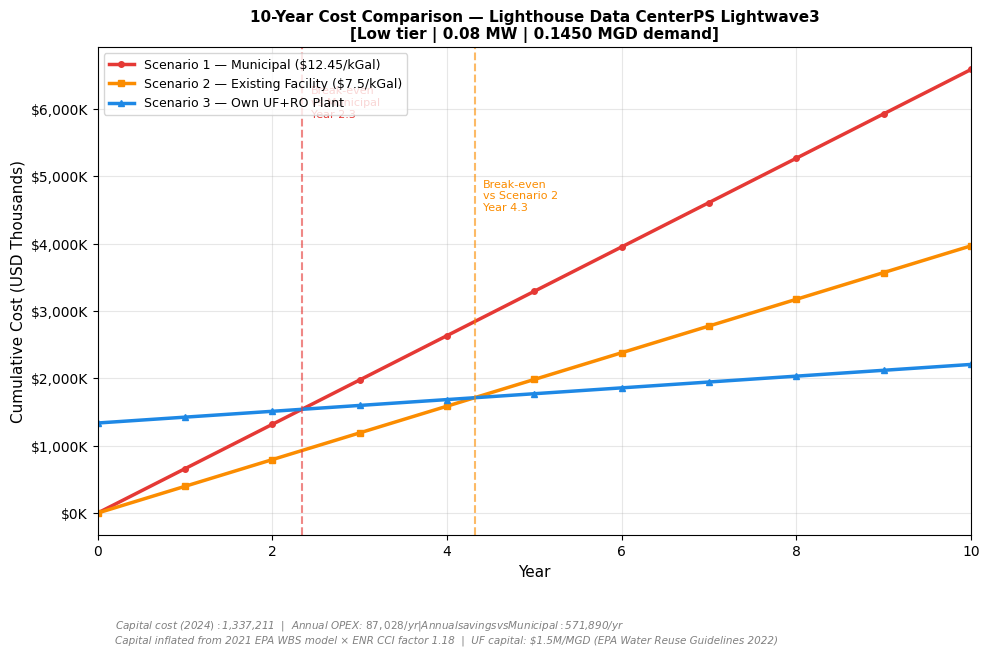

Chart saved: breakeven_Low_0MW.png



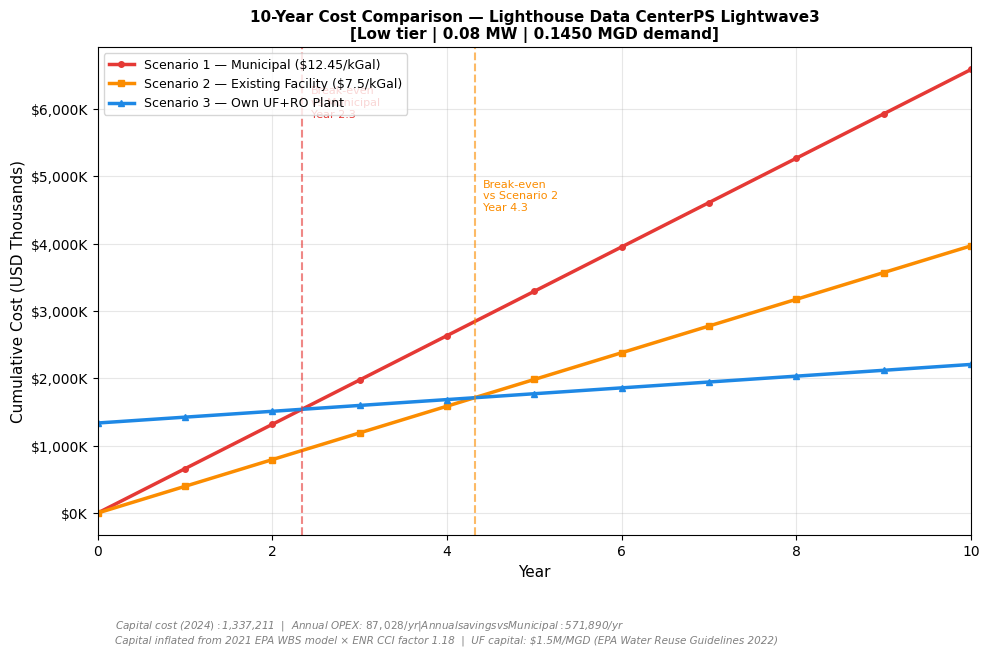

Chart saved: breakeven_Low_0MW.png



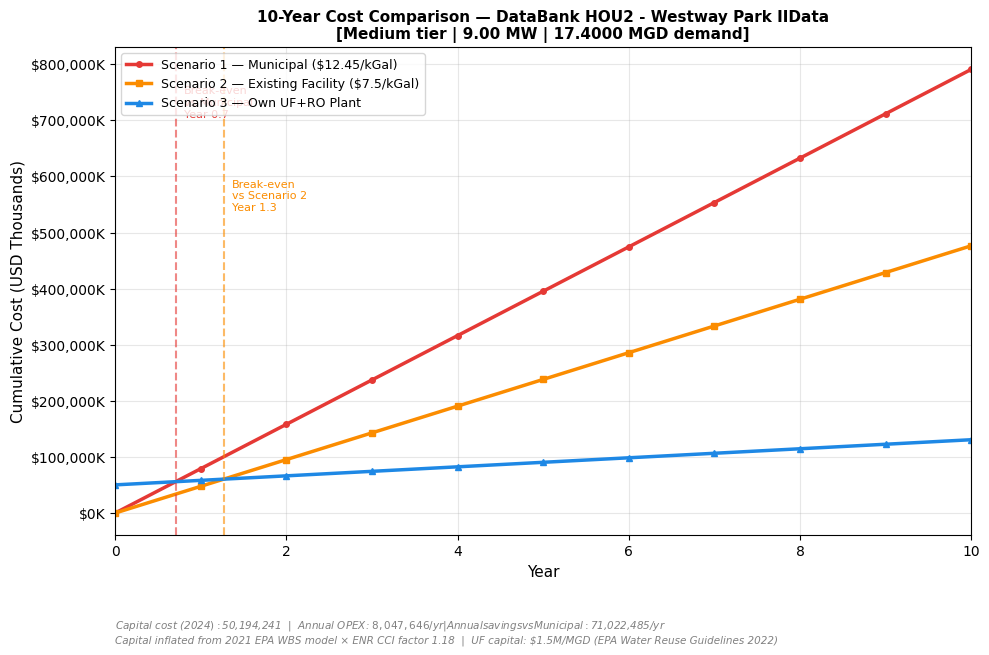

Chart saved: breakeven_Medium_9MW.png



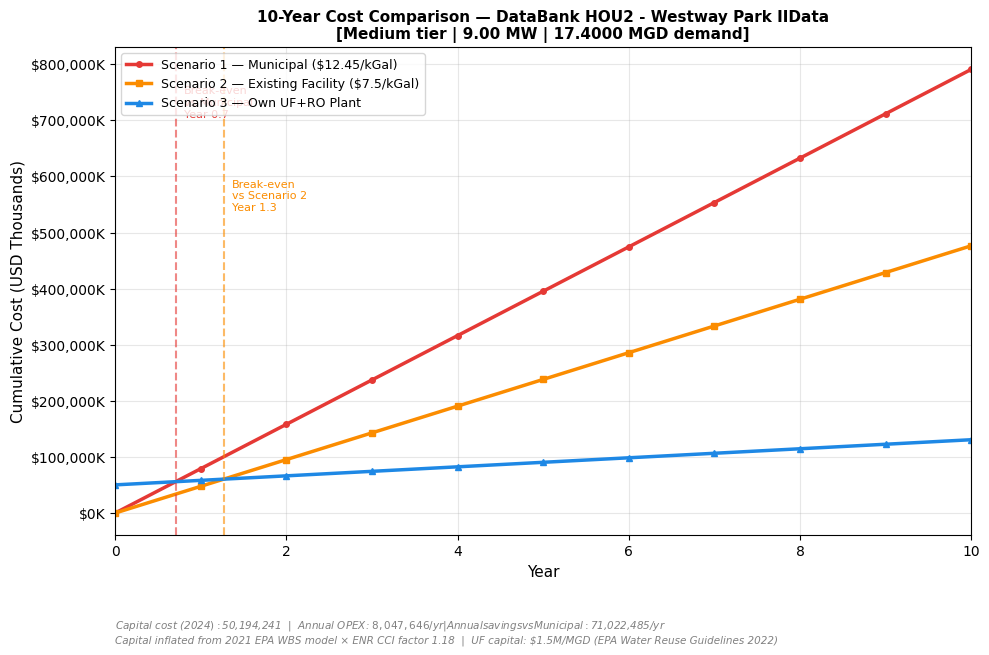

Chart saved: breakeven_Medium_9MW.png



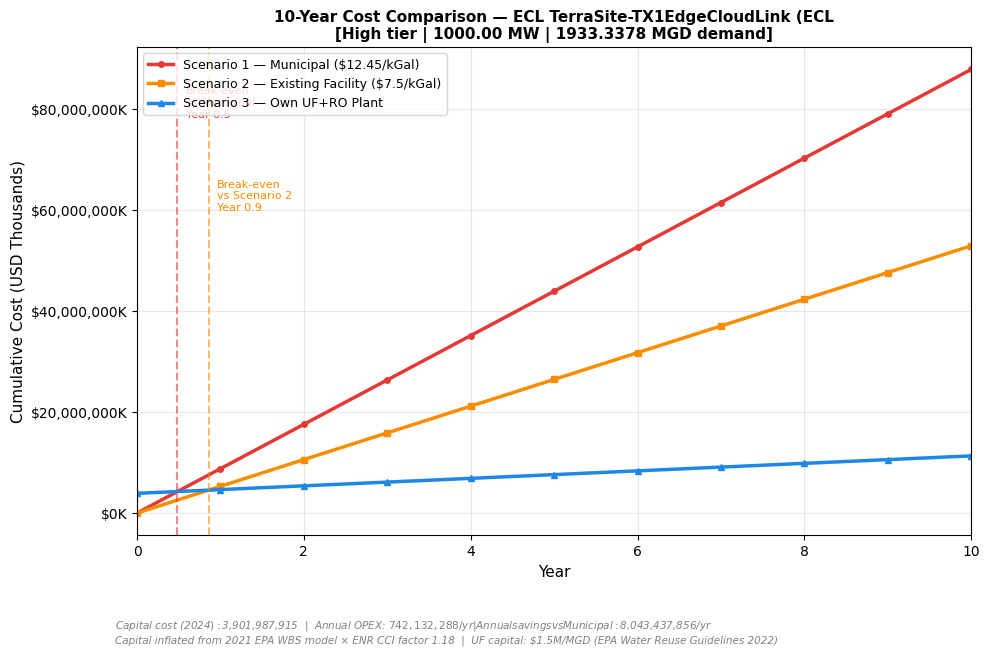

Chart saved: breakeven_High_1000MW.png



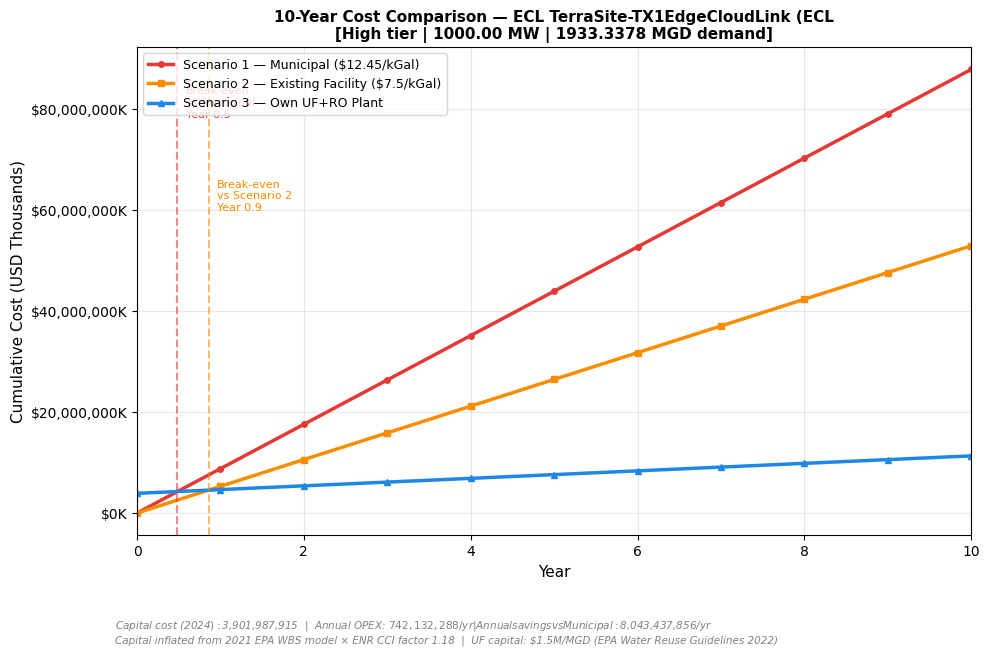

Chart saved: breakeven_High_1000MW.png



In [ ]:
# ============================================================
# SECTION 10 — Plot individual break-even chart per facility
# ============================================================
# What this does: Creates one separate chart per facility
# so values are never cut off or crowded.
# Each chart shows all 3 scenarios over 10 years with the
# break-even point clearly marked.
# ============================================================

colors = {
    "s1": "#E53935",   # Red — Municipal (most expensive)
    "s2": "#FB8C00",   # Orange — Existing facility
    "s3": "#1E88E5",   # Blue — Own plant
}

for f in facility_curves:
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(years, [v/1000 for v in f["cum_s1"]],
            color=colors["s1"], linewidth=2.5, marker="o",
            markersize=4, label=f"Scenario 1 — Municipal (${RATE_MUNICIPAL}/kGal)")
    ax.plot(years, [v/1000 for v in f["cum_s2"]],
            color=colors["s2"], linewidth=2.5, marker="s",
            markersize=4, label=f"Scenario 2 — Existing Facility (${RATE_SCENARIO2}/kGal)")
    ax.plot(years, [v/1000 for v in f["cum_s3"]],
            color=colors["s3"], linewidth=2.5, marker="^",
            markersize=4, label="Scenario 3 — Own UF+RO Plant")

    if f["be_s1"] < ANALYSIS_YEARS:
        ax.axvline(x=f["be_s1"], color=colors["s1"],
                   linestyle="--", alpha=0.6, linewidth=1.5)
        ax.text(f["be_s1"] + 0.1,
                ax.get_ylim()[1] * 0.85,
                f"Break-even\nvs Municipal\nYear {f['be_s1']:.1f}",
                fontsize=8, color=colors["s1"])

    if f["be_s2"] < ANALYSIS_YEARS:
        ax.axvline(x=f["be_s2"], color=colors["s2"],
                   linestyle="--", alpha=0.6, linewidth=1.5)
        ax.text(f["be_s2"] + 0.1,
                ax.get_ylim()[1] * 0.65,
                f"Break-even\nvs Scenario 2\nYear {f['be_s2']:.1f}",
                fontsize=8, color=colors["s2"])

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Cumulative Cost (USD Thousands)", fontsize=11)
    ax.set_title(
        f"10-Year Cost Comparison — {f['name']}\n"
        f"[{f['tier']} tier | {f['cap_mw']:.2f} MW | "
        f"{f['mid_mgd']:.4f} MGD demand]",
        fontsize=11, fontweight="bold")
    ax.legend(fontsize=9, loc="upper left")
    ax.set_xlim(0, ANALYSIS_YEARS)
    ax.grid(True, alpha=0.3)

    fig.text(0.12, -0.08,
        f"Capital cost (2024$): ${f['capital']:,.0f}  |  "
        f"Annual OPEX: ${f['s3_opex']:,.0f}/yr  |  "
        f"Annual savings vs Municipal: ${f['s1_annual']-f['s3_opex']:,.0f}/yr\n"
        f"Capital inflated from 2021 EPA WBS model × ENR CCI factor 1.18  |  "
        f"UF capital: $1.5M/MGD (EPA Water Reuse Guidelines 2022)",
        fontsize=7.5, style="italic", color="gray",
        transform=fig.transFigure)

    plt.tight_layout()
    fname = f"breakeven_{f['tier']}_{f['cap_mw']:.0f}MW.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Chart saved: {fname}")
    print()

**EPA Cost Curve Chart**

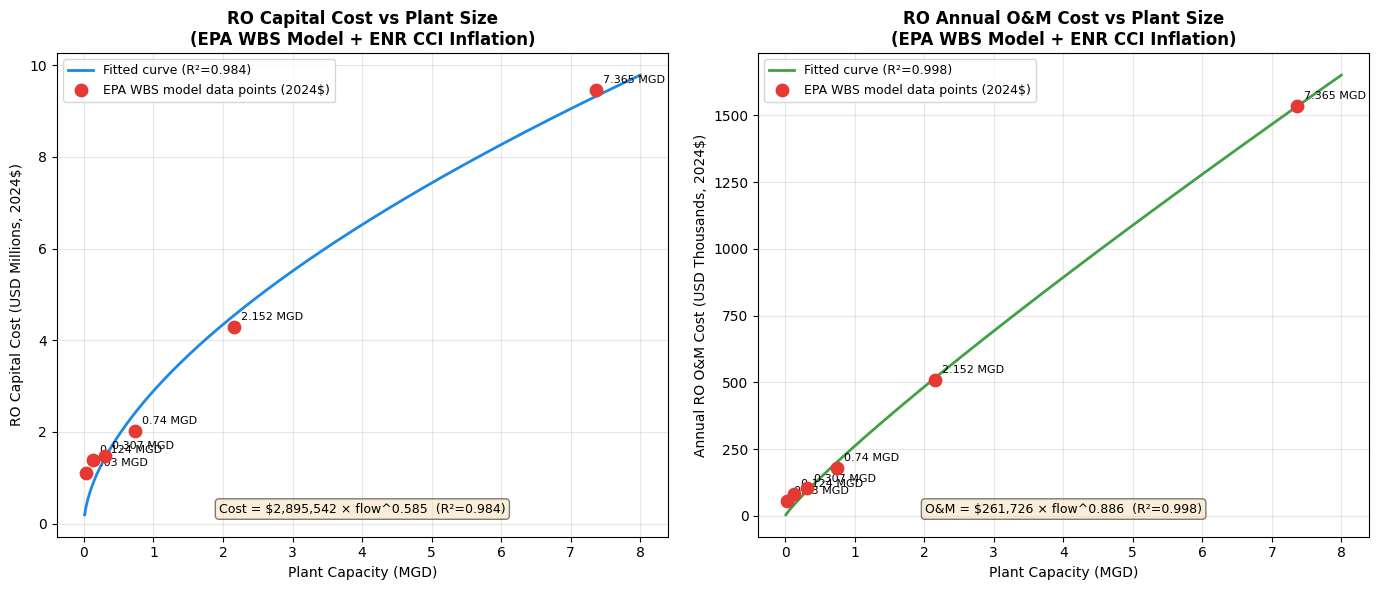

EPA cost curves saved: epa_cost_curves.png


In [ ]:
# ============================================================
# SECTION 11 — Plot EPA WBS cost curve
# ============================================================
# What this does: Shows the power law curve fitted to the
# 6 EPA data points. This is your methodological transparency
# chart — shows reviewers exactly how capital costs were
# derived across different plant sizes.
# ============================================================

flow_range = np.linspace(0.01, 8, 500)
cap_curve  = power_law(flow_range, *cap_params) * 1  # already 2024$
om_curve   = power_law(flow_range, *om_params)  * 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Capital cost curve
ax1.plot(flow_range, cap_curve/1e6, color="#1E88E5",
         linewidth=2, label=f"Fitted curve (R²={cap_r2:.3f})")
ax1.scatter(epa_flows, epa_capital_2024/1e6, color="#E53935",
            s=80, zorder=5, label="EPA WBS model data points (2024$)")
for i, (x, y) in enumerate(zip(epa_flows, epa_capital_2024)):
    ax1.annotate(f"{x} MGD", (x, y/1e6),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)
ax1.set_xlabel("Plant Capacity (MGD)")
ax1.set_ylabel("RO Capital Cost (USD Millions, 2024$)")
ax1.set_title("RO Capital Cost vs Plant Size\n(EPA WBS Model + ENR CCI Inflation)",
              fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.text(0.5, 0.05,
         f"Cost = ${cap_params[0]:,.0f} × flow^{cap_params[1]:.3f}  (R²={cap_r2:.3f})",
         transform=ax1.transAxes, fontsize=9, ha="center",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# O&M cost curve
ax2.plot(flow_range, om_curve/1e3, color="#43A047",
         linewidth=2, label=f"Fitted curve (R²={om_r2:.3f})")
ax2.scatter(epa_flows, epa_om_2024/1e3, color="#E53935",
            s=80, zorder=5, label="EPA WBS model data points (2024$)")
for i, (x, y) in enumerate(zip(epa_flows, epa_om_2024)):
    ax2.annotate(f"{x} MGD", (x, y/1e3),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)
ax2.set_xlabel("Plant Capacity (MGD)")
ax2.set_ylabel("Annual RO O&M Cost (USD Thousands, 2024$)")
ax2.set_title("RO Annual O&M Cost vs Plant Size\n(EPA WBS Model + ENR CCI Inflation)",
              fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.text(0.5, 0.05,
         f"O&M = ${om_params[0]:,.0f} × flow^{om_params[1]:.3f}  (R²={om_r2:.3f})",
         transform=ax2.transAxes, fontsize=9, ha="center",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.savefig("epa_cost_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("EPA cost curves saved: epa_cost_curves.png")

**LCOW Comparison Chart**

3 REPRESENTATIVE FACILITIES — SAVINGS CHARTS
Axis: Month 4 | Month 8 | Month 12 | Year 2 | Year 3 | Year 4

  [Low] Lighthouse Data CenterPS Lightwave3
  Capacity        : 0.08 MW
  Mid demand      : 0.1450 MGD
  S3 Capital      : $1,337,211
  S2 monthly save : $21,832/month
  S3 monthly save : $47,658/month
  Break-even      : 28.1 months (2.34 years)


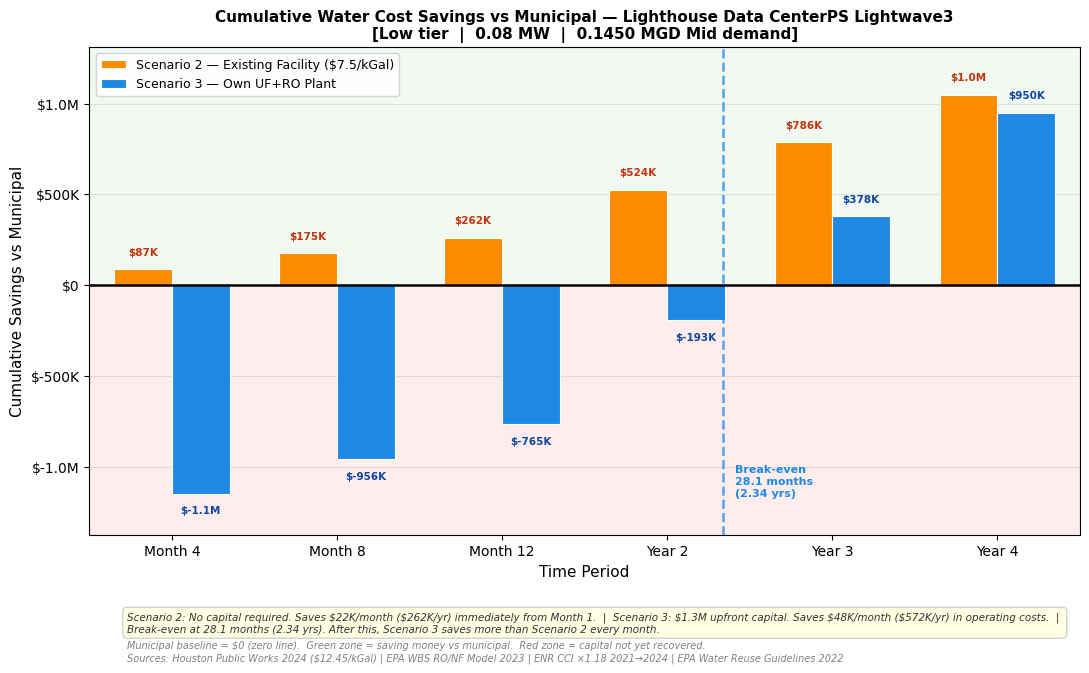

  Chart saved: savings_low_0MW.png


  [Medium] Iozera HoustonIozera11631 Roark Rd7
  Capacity        : 10.00 MW
  Mid demand      : 19.3334 MGD
  S3 Capital      : $54,937,104
  S2 monthly save : $2,910,882/month
  S3 monthly save : $6,579,800/month
  Break-even      : 8.3 months (0.70 years)


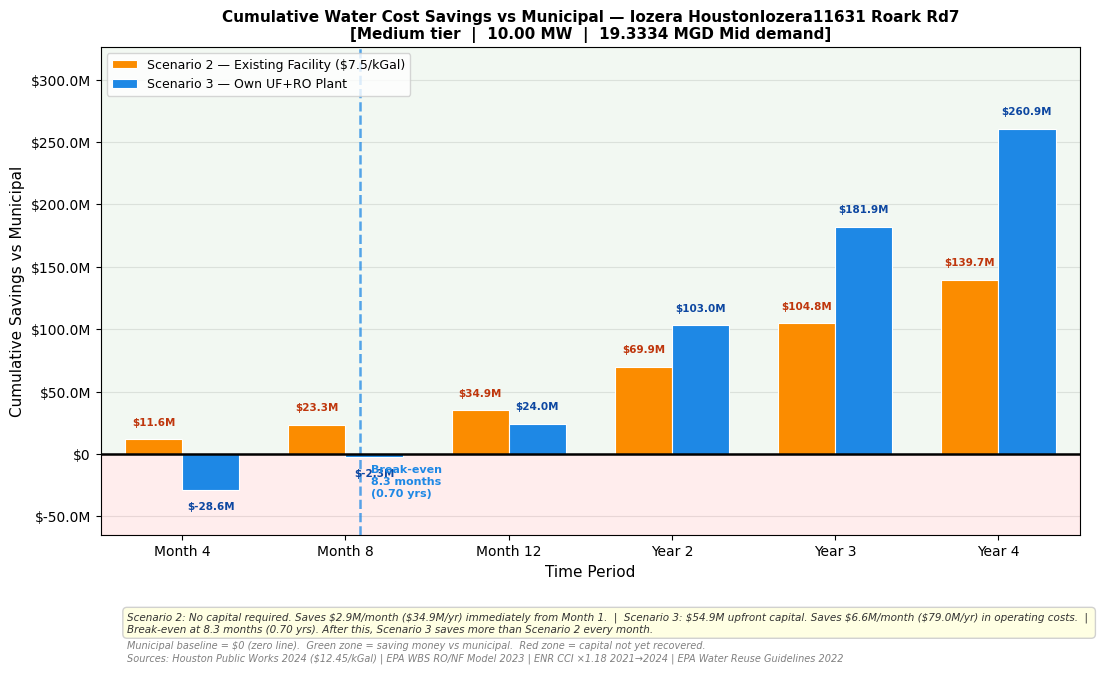

  Chart saved: savings_medium_10MW.png


  [High] ECL TerraSite-TX1EdgeCloudLink (ECL
  Capacity        : 1000.00 MW
  Mid demand      : 1933.3378 MGD
  S3 Capital      : $3,901,987,915
  S2 monthly save : $291,088,167/month
  S3 monthly save : $670,286,488/month
  Break-even      : 5.8 months (0.49 years)


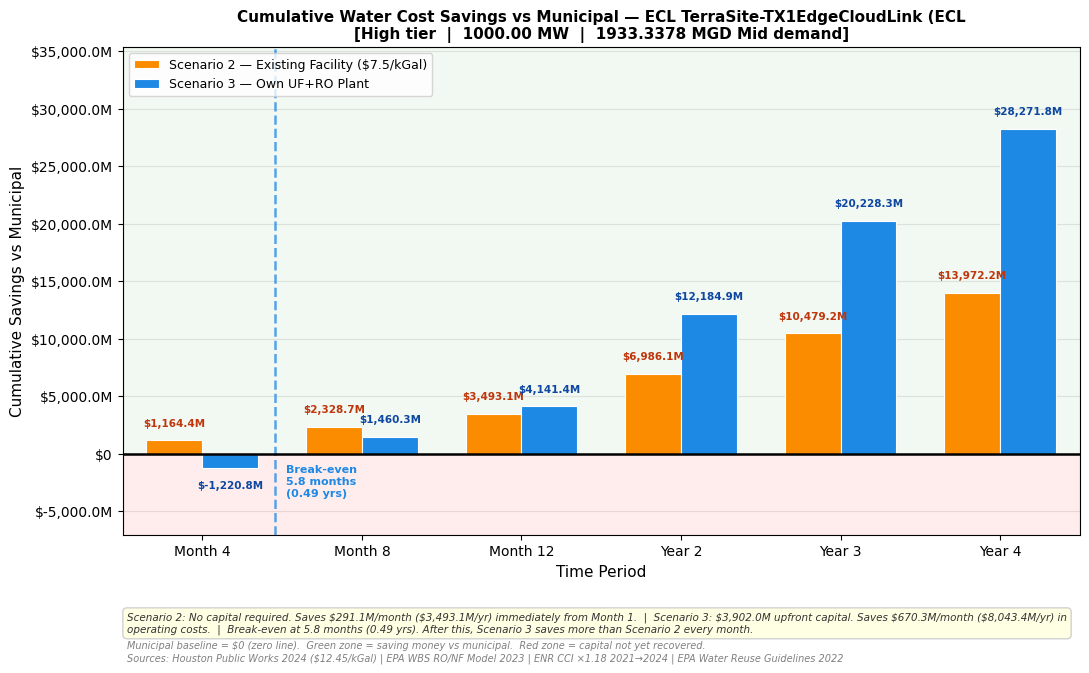

  Chart saved: savings_high_1000MW.png

ALL 3 CHARTS COMPLETE

KEY FINDING ACROSS 3 CHARTS:
  Low tier    → break-even later, Scenario 2 safer short-term
  Medium tier → break-even within months, Scenario 3 pulls ahead fast
  High tier   → fastest break-even, Scenario 3 dominant strategy

  Same time axis across all 3 = audience can directly
  compare how facility size determines which strategy wins


In [ ]:
# ============================================================
# SECTION 12 — 3 Facility Savings Charts — FINAL VERSION
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- Select 3 facilities ---
df_sorted3 = df.sort_values(COL_CAP).reset_index(drop=True)
n = len(df_sorted3)

selected_3 = [
    {"data": df_sorted3.iloc[0],    "tier": "Low"},
    {"data": df_sorted3.iloc[n//2], "tier": "Medium"},
    {"data": df_sorted3.iloc[-1],   "tier": "High"},
]

# --- Time axis ---
time_months = [4, 8, 12, 24, 36, 48]
time_labels = ["Month 4", "Month 8", "Month 12",
               "Year 2",  "Year 3",  "Year 4"]

# --- Smart formatters ---
def smart_format(value):
    """Format number to readable scale automatically."""
    abs_val = abs(value)
    if abs_val >= 1_000_000:
        return f"${value/1_000_000:,.1f}M"
    elif abs_val >= 1_000:
        return f"${value/1_000:,.0f}K"
    else:
        return f"${value:,.0f}"

def smart_axis_formatter(value, pos):
    """For y axis tick labels."""
    abs_val = abs(value)
    if abs_val >= 1_000_000:
        return f"${value/1_000_000:,.1f}M"
    elif abs_val >= 1_000:
        return f"${value/1_000:,.0f}K"
    else:
        return f"${value:,.0f}"

print("=" * 60)
print("3 REPRESENTATIVE FACILITIES — SAVINGS CHARTS")
print("Axis: Month 4 | Month 8 | Month 12 | Year 2 | Year 3 | Year 4")
print("=" * 60)

# --- Plot one chart per facility ---
for f in selected_3:
    row        = f["data"]
    tier       = f["tier"]
    name       = str(row[COL_NAME])[:35]
    cap_mw     = row[COL_CAP]
    mid_mgd    = row["Mid_MGD"]
    s1_annual  = row["S1_Annual_USD"]
    s2_annual  = row["S2_Annual_USD"]
    s3_opex    = row["S3_Annual_OPEX"]
    s3_capital = row["S3_Capital_USD"]

    # Monthly saving rates (raw dollars)
    rate_s2 = (s1_annual - s2_annual) / 12
    rate_s3 = (s1_annual - s3_opex)   / 12

    # Cumulative values at each time point (raw dollars)
    vals_s2 = [m * rate_s2               for m in time_months]
    vals_s3 = [-s3_capital + m * rate_s3  for m in time_months]

    # Break-even calculation
    if rate_s3 > 0:
        be_months = s3_capital / rate_s3
        be_years  = be_months / 12
    else:
        be_months = None
        be_years  = None

    # Print summary
    print(f"\n  [{tier}] {name}")
    print(f"  Capacity        : {cap_mw:.2f} MW")
    print(f"  Mid demand      : {mid_mgd:.4f} MGD")
    print(f"  S3 Capital      : ${s3_capital:,.0f}")
    print(f"  S2 monthly save : ${rate_s2:,.0f}/month")
    print(f"  S3 monthly save : ${rate_s3:,.0f}/month")
    if be_months:
        print(f"  Break-even      : {be_months:.1f} months "
              f"({be_years:.2f} years)")

    # ── Axis limits ────────────────────────────────────────
    all_vals = vals_s2 + vals_s3
    data_max = max(all_vals)
    data_min = min(all_vals)

    ax_max = data_max * 1.25
    if ax_max <= 0:
        ax_max = abs(data_min) * 0.30

    # Negative region must be at least 20% of total chart height
    # This ensures negative bars are always clearly visible
    # regardless of how large the positive values are
    natural_min = data_min * 1.20
    minimum_min = -ax_max * 0.20

    ax_min = min(natural_min, minimum_min)

    if ax_min >= 0:
        ax_min = -ax_max * 0.20

    label_pad = (ax_max - ax_min) * 0.025

    # ── Draw chart ─────────────────────────────────────────
    x     = np.arange(len(time_labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(11, 6))

    # Background shading
    ax.axhspan(0,      ax_max, alpha=0.05, color="green", zorder=1)
    ax.axhspan(ax_min, 0,      alpha=0.07, color="red",   zorder=1)

    # Zero line
    ax.axhline(y=0, color="black", linewidth=1.8, zorder=5)

    # Bars
    b2 = ax.bar(
        x - width/2, vals_s2, width,
        color="#FB8C00", edgecolor="white", linewidth=0.8,
        label=f"Scenario 2 — Existing Facility "
              f"(${RATE_SCENARIO2}/kGal)",
        zorder=3
    )
    b3 = ax.bar(
        x + width/2, vals_s3, width,
        color="#1E88E5", edgecolor="white", linewidth=0.8,
        label="Scenario 3 — Own UF+RO Plant",
        zorder=3
    )

    # ── Value labels — Scenario 2 ──────────────────────────
    for bar, val in zip(b2, vals_s2):
        if val >= 0:
            ypos = min(val + label_pad, ax_max * 0.92)
            va   = "bottom"
        else:
            ypos = max(val - label_pad, ax_min * 0.92)
            va   = "top"
        ax.text(
            bar.get_x() + bar.get_width() / 2, ypos,
            smart_format(val),
            ha="center", va=va,
            fontsize=7.5, fontweight="bold",
            color="#BF360C", zorder=6
        )

    # ── Value labels — Scenario 3 ──────────────────────────
    for bar, val in zip(b3, vals_s3):
        if val >= 0:
            ypos = min(val + label_pad, ax_max * 0.92)
            va   = "bottom"
        else:
            # If bar extends below visible area show arrow label
            bar_bottom = bar.get_height()
            if bar_bottom < ax_min:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    ax_min + label_pad,
                    f"▼ {smart_format(val)}",
                    ha="center", va="bottom",
                    fontsize=7, fontweight="bold",
                    color="#0D47A1", zorder=6
                )
                continue
            ypos = max(val - label_pad, ax_min * 0.92)
            va   = "top"

        ax.text(
            bar.get_x() + bar.get_width() / 2, ypos,
            smart_format(val),
            ha="center", va=va,
            fontsize=7.5, fontweight="bold",
            color="#0D47A1", zorder=6
        )

    # ── Break-even vertical line ───────────────────────────
    if be_months is not None and be_months <= 48:
        for i in range(len(time_months) - 1):
            if time_months[i] <= be_months <= time_months[i+1]:
                frac = ((be_months - time_months[i]) /
                        (time_months[i+1] - time_months[i]))
                be_x = i + frac
                ax.axvline(
                    x=be_x, color="#1E88E5",
                    linestyle="--", alpha=0.75,
                    linewidth=1.8, zorder=4
                )
                # Place label in negative zone so it does not
                # overlap with bars
                lbl_y = ax_min + (ax_max - ax_min) * 0.08
                ax.text(
                    be_x + 0.07, lbl_y,
                    f"Break-even\n{be_months:.1f} months\n"
                    f"({be_years:.2f} yrs)",
                    fontsize=8, color="#1E88E5",
                    fontweight="bold", zorder=7
                )
                break

    # ── Axis formatting ────────────────────────────────────
    ax.set_axisbelow(True)
    ax.set_xlim(-0.5, len(time_labels) - 0.5)
    ax.set_ylim(ax_min, ax_max)
    ax.set_xticks(x)
    ax.set_xticklabels(time_labels, fontsize=10)
    ax.set_xlabel("Time Period", fontsize=11)
    ax.set_ylabel("Cumulative Savings vs Municipal", fontsize=11)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(smart_axis_formatter))
    ax.set_title(
        f"Cumulative Water Cost Savings vs Municipal — {name}\n"
        f"[{tier} tier  |  {cap_mw:.2f} MW  |  "
        f"{mid_mgd:.4f} MGD Mid demand]",
        fontsize=11, fontweight="bold"
    )
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(True, alpha=0.3, axis="y", zorder=2)

    # ── Explanation box ────────────────────────────────────
    if be_months is not None:
        if be_months <= 48:
            be_txt = (
                f"Break-even at {be_months:.1f} months "
                f"({be_years:.2f} yrs). After this, Scenario 3 "
                f"saves more than Scenario 2 every month."
            )
        else:
            be_txt = (
                f"Break-even at {be_months:.1f} months "
                f"({be_years:.2f} yrs) — beyond 4-year window shown."
            )
    else:
        be_txt = "Capital not recovered within 4-year window."

    fig.text(
        0.12, -0.06,
        f"Scenario 2: No capital required. "
        f"Saves {smart_format(rate_s2)}/month "
        f"({smart_format(rate_s2*12)}/yr) immediately from Month 1.  |  "
        f"Scenario 3: {smart_format(s3_capital)} upfront capital. "
        f"Saves {smart_format(rate_s3)}/month "
        f"({smart_format(rate_s3*12)}/yr) in operating costs.  |  "
        f"{be_txt}",
        fontsize=7.5, style="italic", color="#333333",
        wrap=True,
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="lightyellow",
            edgecolor="#cccccc", alpha=0.9
        )
    )

    fig.text(
        0.12, -0.11,
        "Municipal baseline = $0 (zero line).  "
        "Green zone = saving money vs municipal.  "
        "Red zone = capital not yet recovered.\n"
        f"Sources: Houston Public Works 2024 "
        f"(${RATE_MUNICIPAL}/kGal) | "
        f"EPA WBS RO/NF Model 2023 | "
        f"ENR CCI ×{ENR_INFLATION} 2021→2024 | "
        f"EPA Water Reuse Guidelines 2022",
        fontsize=7, style="italic", color="gray"
    )

    plt.tight_layout()
    fname = f"savings_{tier.lower()}_{cap_mw:.0f}MW.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Chart saved: {fname}")
    print()

print("=" * 60)
print("ALL 3 CHARTS COMPLETE")
print("=" * 60)
print()
print("KEY FINDING ACROSS 3 CHARTS:")
print("  Low tier    → break-even later, Scenario 2 safer "
      "short-term")
print("  Medium tier → break-even within months, "
      "Scenario 3 pulls ahead fast")
print("  High tier   → fastest break-even, "
      "Scenario 3 dominant strategy")
print()
print("  Same time axis across all 3 = audience can directly")
print("  compare how facility size determines which strategy wins")

**Export Excel and Download**

In [ ]:
# ============================================================
# SECTION 13 — Export results to Excel and download all files
# ============================================================
from google.colab import files
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment

OUTPUT_EXCEL = "Houston_Water_Economic_Analysis.xlsx"

df_out = df[[COL_NAME, COL_CAP, "Mid_MGD", "High_MGD",
             "S1_Annual_USD", "S2_Annual_USD",
             "S3_Capital_USD", "S3_UF_Capital", "S3_RO_Capital",
             "S3_Annual_OPEX",
             "Save_S2_vs_S1_Annual", "Save_S3_vs_S1_Annual",
             "Breakeven_S3_vs_S1", "Breakeven_S3_vs_S2",
             "LCOW_S1", "LCOW_S2", "LCOW_S3"]].copy()

df_out.columns = [
    "Data Center Name", "Capacity (MW)",
    "Mid Demand (MGD)", "High Demand (MGD)",
    "S1 Municipal Annual ($)", "S2 Existing Facility Annual ($)",
    "S3 Total Plant Capital ($)", "S3 UF Capital ($)", "S3 RO Capital ($)",
    "S3 Annual OPEX ($)",
    "Savings S2 vs Municipal ($/yr)", "Savings S3 vs Municipal ($/yr)",
    "Break-even S3 vs Municipal (yrs)", "Break-even S3 vs Scenario 2 (yrs)",
    "LCOW S1 ($/kGal)", "LCOW S2 ($/kGal)", "LCOW S3 OPEX only ($/kGal)"
]

df_methodology = pd.DataFrame({
    "Parameter": [
        "Municipal rate",
        "Scenario 2 rate",
        "UF capital cost",
        "UF operating cost",
        "RO capital (EPA WBS curve)",
        "RO O&M (EPA WBS curve)",
        "EPA model base year",
        "ENR CCI inflation factor",
        "Analysis horizon",
        "Plant sizing scenario",
        "Operating cost scenario",
        "Houston wastewater supply",
        "UF+RO recovery rate",
    ],
    "Value": [
        "$12.45/kGal",
        f"${RATE_SCENARIO2}/kGal",
        "$1,500,000/MGD",
        "$0.75/kGal",
        f"${cap_params[0]:,.0f} × MGD^{cap_params[1]:.4f}",
        f"${om_params[0]:,.0f} × MGD^{om_params[1]:.4f}",
        "2021",
        f"×{ENR_INFLATION}",
        f"{ANALYSIS_YEARS} years",
        "High (75% utilization)",
        "Mid (60% utilization)",
        "160 MGD",
        "69%",
    ],
    "Source": [
        "Houston Public Works Rate Schedule 2024",
        "Texas Water Development Board + EPA Water Reuse Guidelines 2022",
        "EPA Water Reuse Guidelines 2022",
        "EPA Water Reuse Guidelines 2022 / Treatment_Costs sheet",
        "EPA WBS RO/NF Model (EPA 815-R-24-027, March 2023)",
        "EPA WBS RO/NF Model (EPA 815-R-24-027, March 2023)",
        "EPA WBS Model documentation",
        "Engineering News Record Construction Cost Index 2021-2024",
        "Data center industry standard investment horizon",
        "Engineering design standard (size for worst case)",
        "Lawrence Berkeley National Lab utilization data",
        "Houston City Annual Water Report / TCEQ permits",
        "EPA Water Reuse Guidelines 2022",
    ]
})

with pd.ExcelWriter(OUTPUT_EXCEL, engine="openpyxl") as writer:
    df_out.to_excel(writer, sheet_name="Per_Facility_Costs", index=False)
    df_methodology.to_excel(writer, sheet_name="Methodology_Citations", index=False)

wb = load_workbook(OUTPUT_EXCEL)
hfill = PatternFill("solid", fgColor="1F4E79")
hfont = Font(bold=True, color="FFFFFF", size=10)
for ws in wb.worksheets:
    for cell in ws[1]:
        cell.fill = hfill
        cell.font = hfont
        cell.alignment = Alignment(horizontal="center", wrap_text=True)
    ws.row_dimensions[1].height = 35
    for col in ws.columns:
        max_len = max((len(str(c.value or "")) for c in col), default=10)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 45)
wb.save(OUTPUT_EXCEL)

print(f"Excel saved: {OUTPUT_EXCEL}")
print()
print("Downloading all output files...")
files.download(OUTPUT_EXCEL)
for f in facility_curves:
    fname = f"breakeven_{f['tier']}_{f['cap_mw']:.0f}MW.png"
    try:
        files.download(fname)
    except:
        pass
files.download("epa_cost_curves.png")
files.download("lcow_comparison.png")
print()
print("All files downloaded.")
print()
print("OUTPUT FILES:")
print("  Houston_Water_Economic_Analysis.xlsx")
print("    Sheet 1: Per_Facility_Costs — all 25+ data centers")
print("    Sheet 2: Methodology_Citations — every number sourced")
print("  epa_cost_curves.png — capital and O&M curves from EPA data")
print("  lcow_comparison.png — LCOW bar chart, all 6 facilities")
print("  breakeven_[tier]_[MW].png — individual chart per facility (×6)")

Excel saved: Houston_Water_Economic_Analysis.xlsx



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All files downloaded.

OUTPUT FILES:
  Houston_Water_Economic_Analysis.xlsx
    Sheet 1: Per_Facility_Costs — all 25+ data centers
    Sheet 2: Methodology_Citations — every number sourced
  epa_cost_curves.png — capital and O&M curves from EPA data
  lcow_comparison.png — LCOW bar chart, all 6 facilities
  breakeven_[tier]_[MW].png — individual chart per facility (×6)
